In [ ]:
import pandas as pd

speeches_df = pd.read_csv('../data/clean/combined_speeches_clean.csv', index_col="date", parse_dates=True)
speeches_df.tail()

,Unnamed: 0,speaker/title,text
date,,,
2021-09-29,571,Makiko Tanaka,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,572,Fumio Kishida,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,573,Koichiro Gemba,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,574,Masahiko Koumura,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,575,Taro Aso,"September 29, 2021\nJapanese\nMinister for For..."


In [22]:
speeches_df.index = pd.to_datetime(speeches_df.index, format="mixed")
speeches_df.tail()

,Unnamed: 0,speaker/title,text
date,,,
2021-09-29,571,Makiko Tanaka,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,572,Fumio Kishida,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,573,Koichiro Gemba,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,574,Masahiko Koumura,"September 29, 2021\nJapanese\nMinister for For..."
2021-09-29,575,Taro Aso,"September 29, 2021\nJapanese\nMinister for For..."


In [23]:
import re
import matplotlib.pyplot as plt
import pandas as pd

from src.keywords import CATEGORY_KEYWORDS 
YEAR_START, YEAR_END = 2004, 2021
COLORS = ["blue", "red", "green", "orange"]

speeches_2004_2021 = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

category_patterns = {
    category: r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b"
    for category, keywords in CATEGORY_KEYWORDS.items()
}
total_per_year = speeches_2004_2021.resample("YE").size().reindex(
    pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0
)

def category_speech_counts(pattern, df):
    matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
    counts = matches.resample("YE").size()
    return counts.reindex(
        pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0
    )

category_year_counts = {
    category: category_speech_counts(pattern, speeches_2004_2021)
    for category, pattern in category_patterns.items()
}

category_year_normalised = {
    category: counts / total_per_year
    for category, counts in category_year_counts.items()
}

rows = []
for category, normalised in category_year_normalised.items():
    for date, value in normalised.items():
        rows.append({
            "category": category,
            "year": date.year,
            "keyword_speeches": category_year_counts[category][date],  # ← ADD
            "total_speeches": total_per_year[date],                    # ← ADD
            "normalised_share": value
        })

speeches_normalised = pd.DataFrame(rows).sort_values(["category", "year"])
speeches_normalised

/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_79966/2396982890.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_79966/2396982890.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_79966/2396982890.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_79966/2396982890.py:22: UserWarning: This pa

,category,year,keyword_speeches,total_speeches,normalised_share
0,defense,2004,2,4,0.500000
1,defense,2005,6,7,0.857143
2,defense,2006,0,3,0.000000
3,defense,2007,1,1,1.000000
4,defense,2008,4,8,0.500000
...,...,...,...,...,...
49,nuclear,2017,14,38,0.368421
50,nuclear,2018,10,22,0.454545
51,nuclear,2019,9,37,0.243243
52,nuclear,2020,8,65,0.123077


In [24]:
speeches_normalised.head(30)

,category,year,keyword_speeches,total_speeches,normalised_share
0,defense,2004,2,4,0.500000
1,defense,2005,6,7,0.857143
2,defense,2006,0,3,0.000000
3,defense,2007,1,1,1.000000
4,defense,2008,4,8,0.500000
5,defense,2009,4,6,0.666667
6,defense,2010,8,12,0.666667
7,defense,2011,19,22,0.863636
8,defense,2012,15,20,0.750000
9,defense,2013,7,8,0.875000


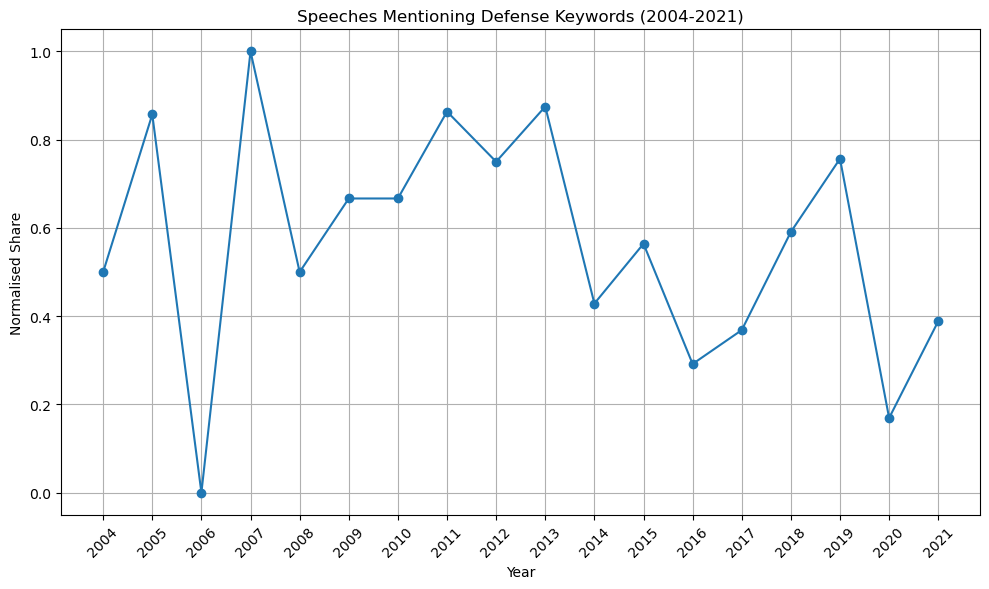

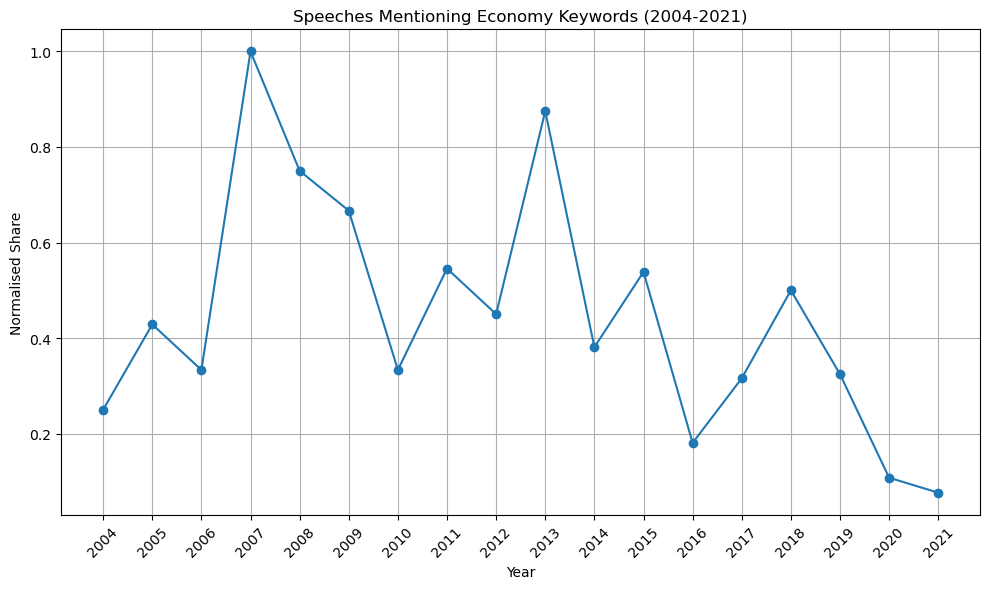

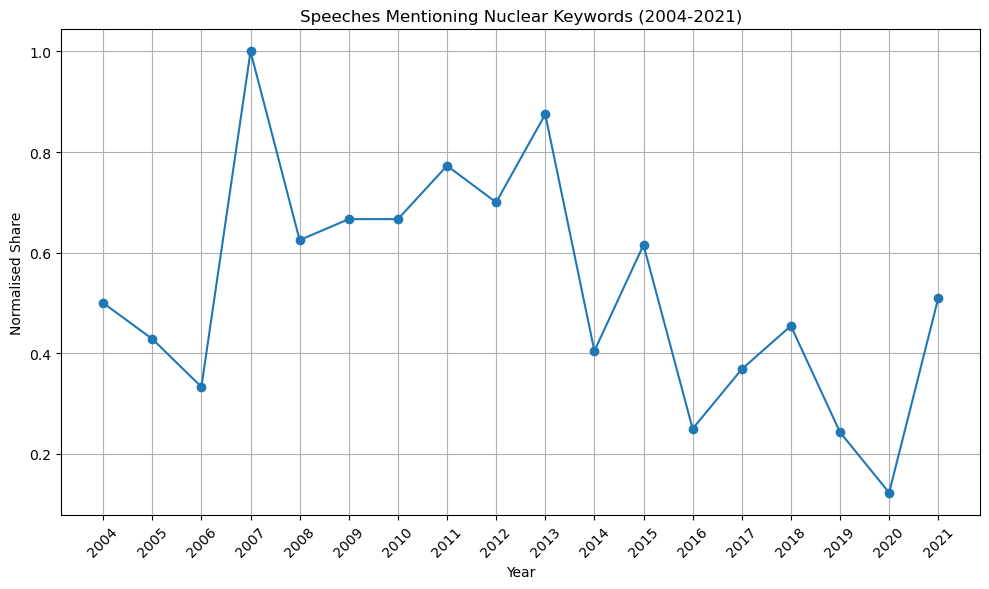

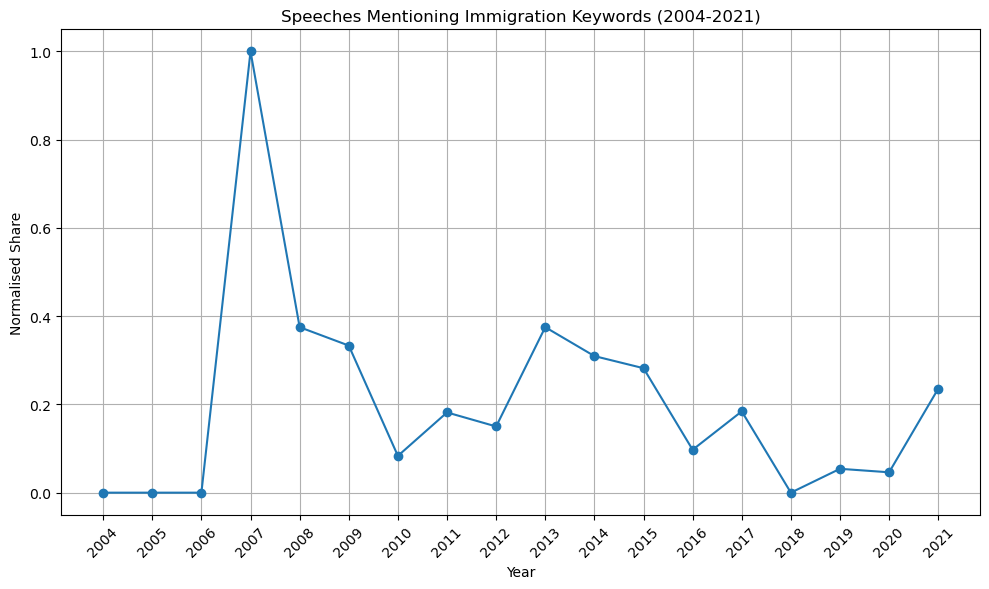

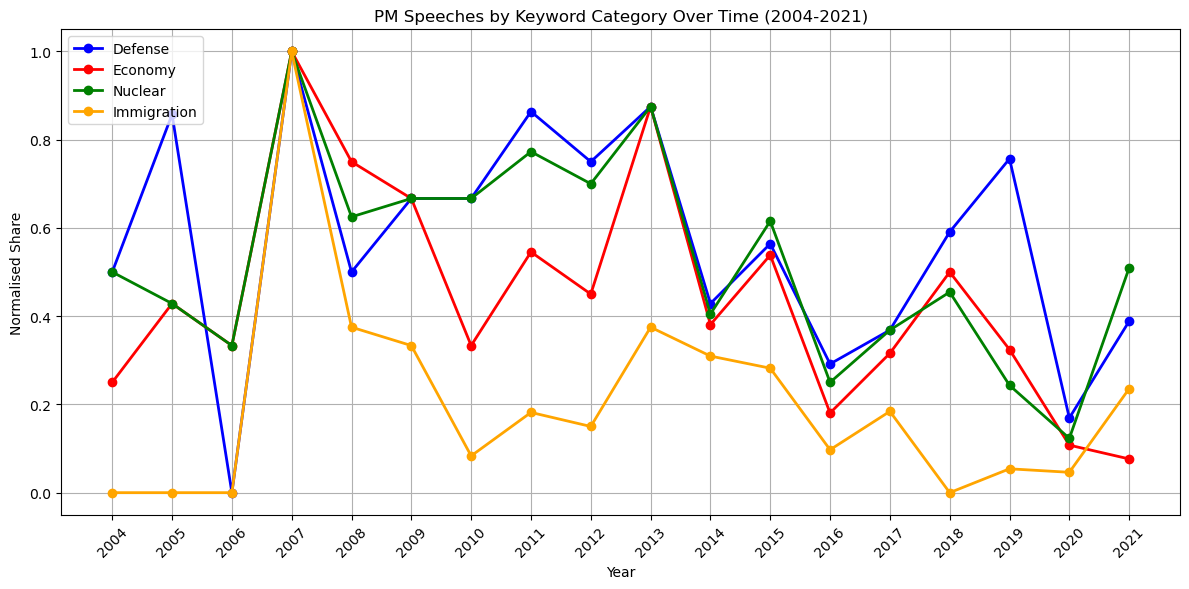

In [25]:
# Individual trend chart per category
for category, normalised in category_year_normalised.items():  # ← CHANGE: counts → normalised
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(normalised.index.year, normalised.values, marker="o")  # ← CHANGE: counts → normalised
    ax.set_xlabel("Year")
    ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
    ax.set_title(f"Speeches Mentioning {category.capitalize()} Keywords ({YEAR_START}-{YEAR_END})")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Combined trend chart, all categories together
fig, ax = plt.subplots(figsize=(12, 6))
for (category, normalised), color in zip(category_year_normalised.items(), COLORS):  # ← CHANGE: counts → normalised
    ax.plot(normalised.index.year, normalised.values, label=category.capitalize(), color=color, marker="o", linewidth=2)  # ← CHANGE: counts → normalised

ax.set_xlabel("Year")
ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
ax.set_title(f"PM Speeches by Keyword Category Over Time ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

In [26]:
speeches_normalised.to_csv('../data/clean/speeches_normalised.csv', index=False)